# 02 · Findings

The analysis. Each section states a claim, shows the evidence, and says what the claim does **not** support.

Full narrative: [`docs/EXECUTIVE_SUMMARY.md`](../docs/EXECUTIVE_SUMMARY.md)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Categorical slots validated for colour-vision-deficiency separation and
# contrast against a light surface (see the project's dataviz palette).
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
plt.rcParams.update({
    "figure.figsize": (10, 4.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.7,
    "axes.titlesize": 12, "axes.titleweight": "semibold",
    "font.size": 10, "axes.labelsize": 10,
})

CURATED = ROOT / "data" / "curated"
SAMPLES = ROOT / "data" / "samples"

def load(name):
    """Read a curated table, falling back to the committed sample CSV."""
    parquet = CURATED / f"{name}.parquet"
    if parquet.exists():
        return pd.read_parquet(parquet)
    return pd.read_csv(SAMPLES / f"{name}.csv")

print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 2.0.3 | numpy 1.26.4


In [2]:
gov = load('gov_summary').sort_values('fiscal_year')
fact = load('fact_agency_year') if (CURATED/'fact_agency_year.parquet').exists() \
       else load('fact_agency_year_material')
first, last, prev = gov.iloc[0], gov.iloc[-1], gov.iloc[-2]
BASE, LATEST = int(first.fiscal_year), int(last.fiscal_year)
print(f'window FY{BASE}-FY{LATEST} | total obligations ${gov.obligations.sum()/1e12:.2f}T')

window FY2021-FY2025 | total obligations $3.58T


## Finding 1 — Most of the growth is the price level

A statement about federal spending 'growth' that does not name a deflator is describing inflation.

In [3]:
nom = (last.obligations / first.obligations - 1) * 100
real = (last.obligations_real / first.obligations_real - 1) * 100
price_only = last.obligations - first.obligations * (last.obligations_real / first.obligations_real)
print(f'FY{BASE} -> FY{LATEST}')
print(f'  nominal growth : {nom:+.2f}%   (${first.obligations/1e9:,.1f}B -> ${last.obligations/1e9:,.1f}B)')
print(f'  real growth    : {real:+.2f}%   (constant FY{LATEST} dollars)')
print(f'  price level    : ${price_only/1e9:,.1f}B of the ${(last.obligations-first.obligations)/1e9:,.1f}B increase')

FY2021 -> FY2025
  nominal growth : +22.94%   ($633.2B -> $778.4B)
  real growth    : +4.28%   (constant FY2025 dollars)
  price level    : $118.2B of the $145.3B increase


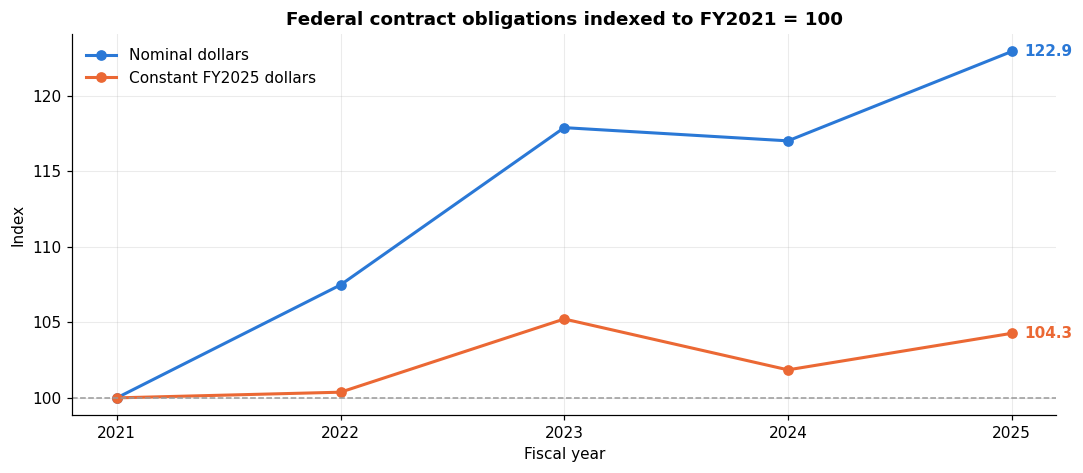

In [4]:
fig, ax = plt.subplots()
x = gov.fiscal_year.astype(int)
ax.plot(x, gov.obligations_index_vs_base, 'o-', color=BLUE, lw=2, label='Nominal dollars')
ax.plot(x, gov.obligations_real_index_vs_base, 'o-', color=ORANGE, lw=2,
        label=f'Constant FY{LATEST} dollars')
ax.axhline(100, color='#999', ls='--', lw=1)
for series, colour in ((gov.obligations_index_vs_base, BLUE),
                       (gov.obligations_real_index_vs_base, ORANGE)):
    ax.annotate(f'{series.iloc[-1]:.1f}', (x.iloc[-1], series.iloc[-1]),
                textcoords='offset points', xytext=(8, -3), color=colour, weight='bold')
ax.set(title=f'Federal contract obligations indexed to FY{BASE} = 100',
       xlabel='Fiscal year', ylabel='Index')
ax.set_xticks(x); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## Finding 2 — Competition fell, and the decomposition says why

Two explanations carry opposite management implications:

* **within** — agencies competed less of their own work (behavioural)
* **mix** — dollars moved toward agencies that were already less competitive (compositional)

Shift-share separates them exactly. `S = Σ wᵢ·sᵢ`, and

```
ΔS = Σ wᵢ⁰·Δsᵢ  +  Σ Δwᵢ·(sᵢ⁰ − S⁰)  +  Σ Δwᵢ·Δsᵢ
     within          mix                 interaction
```

In [5]:
from fedspend.metrics.decomposition import shift_share, shift_share_series

d = fact[['fiscal_year','agency_name','obligations','competed_share']].dropna(subset=['competed_share'])
contrib, summ = shift_share(d, group_col='agency_name', weight_col='obligations',
                            rate_col='competed_share', base_period=LATEST-1, latest_period=LATEST)
print(f'FY{LATEST-1} competed share : {summ["rate_base"]*100:.2f}%')
print(f'FY{LATEST} competed share : {summ["rate_latest"]*100:.2f}%')
print(f'total change          : {summ["total_change"]*100:+.2f} pp')
print()
print(f'  within effect       : {summ["within_effect"]*100:+.2f} pp   (behaviour)')
print(f'  mix effect          : {summ["mix_effect"]*100:+.2f} pp   (composition)')
print(f'  interaction         : {summ["interaction_effect"]*100:+.2f} pp')
print(f'  residual            : {summ["reconciliation_residual"]:.2e}  <- exact')

FY2024 competed share : 70.29%
FY2025 competed share : 66.32%
total change          : -3.97 pp

  within effect       : -3.06 pp   (behaviour)
  mix effect          : -0.76 pp   (composition)
  interaction         : -0.15 pp
  residual            : -1.39e-17  <- exact


**The residual is zero to floating-point precision.** The three terms account for the entire observed change, which is what makes this an attribution rather than a narrative.

In [6]:
top = contrib.reindex(contrib.total_effect.abs().sort_values(ascending=False).index).head(8)
out = pd.DataFrame({
    'agency': top.agency_name,
    f'weight FY{LATEST-1} %': (top.w_0*100).round(1),
    f'weight FY{LATEST} %': (top.w_1*100).round(1),
    f'competed FY{LATEST-1} %': (top.s_0*100).round(1),
    f'competed FY{LATEST} %': (top.s_1*100).round(1),
    'within pp': (top.within_effect*100).round(2),
    'mix pp': (top.mix_effect*100).round(2),
    'total pp': (top.total_effect*100).round(2),
})
out.reset_index(drop=True)

,agency,weight FY2024 %,weight FY2025 %,competed FY2024 %,competed FY2025 %,within pp,mix pp,total pp
0,Department of Defense,60.200,63.100,58.000,52.700,-3.170,-0.350,-3.670
1,Department of Health and Human Services,4.000,2.700,90.800,88.500,-0.090,-0.270,-0.330
2,Department of Veterans Affairs,9.000,10.000,92.200,92.200,0.010,0.220,0.230
3,Department of Homeland Security,3.200,3.600,87.800,91.000,0.100,0.080,0.200
4,Agency for International Development,1.000,0.500,96.800,96.800,-0.000,-0.130,-0.130
5,Department of Housing and Urban Development,0.200,0.000,29.900,56.100,0.050,0.080,0.080
6,Department of Agriculture,1.600,1.200,90.100,89.100,-0.020,-0.070,-0.080
7,Department of the Interior,1.100,0.800,90.500,88.600,-0.020,-0.050,-0.070


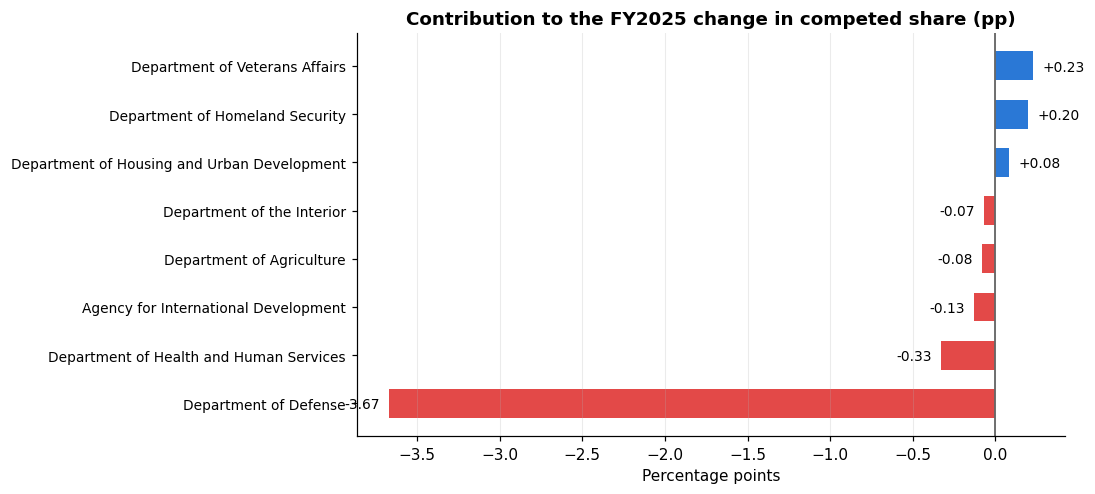

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.6))
t = top.sort_values('total_effect')
vals = (t.total_effect*100).values
ax.barh(range(len(t)), vals, color=[BLUE if v >= 0 else RED for v in vals], height=.6)
ax.set_yticks(range(len(t))); ax.set_yticklabels(t.agency_name, fontsize=9)
ax.axvline(0, color='#666', lw=1.2)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.2f}', (v, i), textcoords='offset points',
                xytext=(6 if v >= 0 else -6, -3), ha='left' if v >= 0 else 'right', fontsize=9)
ax.set(title=f'Contribution to the FY{LATEST} change in competed share (pp)', xlabel='Percentage points')
ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

In [8]:
series = shift_share_series(d, group_col='agency_name', weight_col='obligations',
                            rate_col='competed_share')
s = series.copy()
for c in ['rate_base','rate_latest','total_change','within_effect','mix_effect','interaction_effect']:
    s[c] = (s[c]*100).round(2)
s[['base_period','latest_period','rate_base','rate_latest','total_change',
   'within_effect','mix_effect','interaction_effect']].astype({'base_period':int,'latest_period':int})

,base_period,latest_period,rate_base,rate_latest,total_change,within_effect,mix_effect,interaction_effect
0,2021,2022,65.540,70.040,4.510,4.310,0.250,-0.050
1,2022,2023,70.040,67.810,-2.230,-2.220,0.020,-0.030
2,2023,2024,67.810,70.290,2.480,2.160,0.340,-0.030
3,2024,2025,70.290,66.320,-3.970,-3.060,-0.760,-0.150


> **What this does not show.** Non-competed dollars are not improper dollars. Sole-source awards are frequently lawful and correct. What the measure gives an oversight function is the size of the population where no market test occurred.

## Finding 3 — Year-end concentration

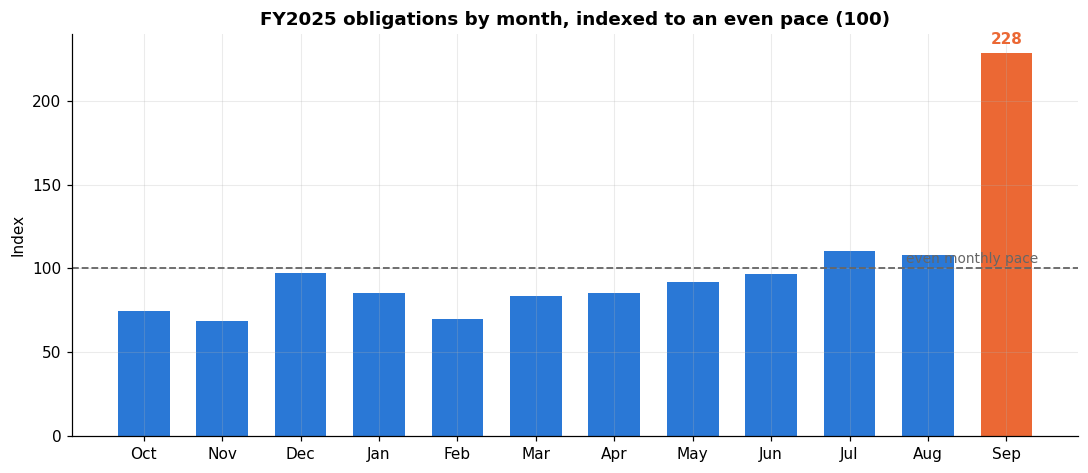

In [9]:
season = load('monthly_seasonality')
latest_season = season[season.fiscal_year == LATEST].sort_values('fiscal_month')
fig, ax = plt.subplots()
colours = [ORANGE if m == 12 else BLUE for m in latest_season.fiscal_month]
ax.bar(range(12), latest_season.index_vs_even_pace, color=colours, width=.66)
ax.axhline(100, color='#666', ls='--', lw=1.2)
ax.annotate('even monthly pace', (11.4, 103), ha='right', fontsize=9, color='#666')
ax.annotate(f'{latest_season.index_vs_even_pace.iloc[-1]:.0f}',
            (11, latest_season.index_vs_even_pace.iloc[-1]), textcoords='offset points',
            xytext=(0, 6), ha='center', color=ORANGE, weight='bold')
ax.set_xticks(range(12)); ax.set_xticklabels(latest_season.month_name)
ax.set(title=f'FY{LATEST} obligations by month, indexed to an even pace (100)', ylabel='Index')
plt.tight_layout(); plt.show()

In [10]:
t = gov[['fiscal_year','september_share','q4_share','surge_ratio','september_excess_obligations']].copy()
t['september %'] = (t.september_share*100).round(2)
t['Q4 %'] = (t.q4_share*100).round(2)
t['surge ratio'] = t.surge_ratio.round(2)
t['$B above even pace'] = (t.september_excess_obligations/1e9).round(1)
t[['fiscal_year','september %','Q4 %','surge ratio','$B above even pace']].astype({'fiscal_year':int})

,fiscal_year,september %,Q4 %,surge ratio,$B above even pace
0,2021,16.930,32.190,146.080,54.400
1,2022,17.940,34.700,154.740,65.400
2,2023,16.240,32.580,139.210,59.100
3,2024,17.630,35.630,154.300,68.900
4,2025,19.020,37.200,167.440,83.400


> **What this does not show.** Programme cycles genuinely land at year end. September concentration is a *risk indicator* that identifies a population worth sampling — awards written against an expiring appropriation, where schedule pressure is highest — not evidence that any individual award was improper.

## Finding 4 — The FY2025 composition shift

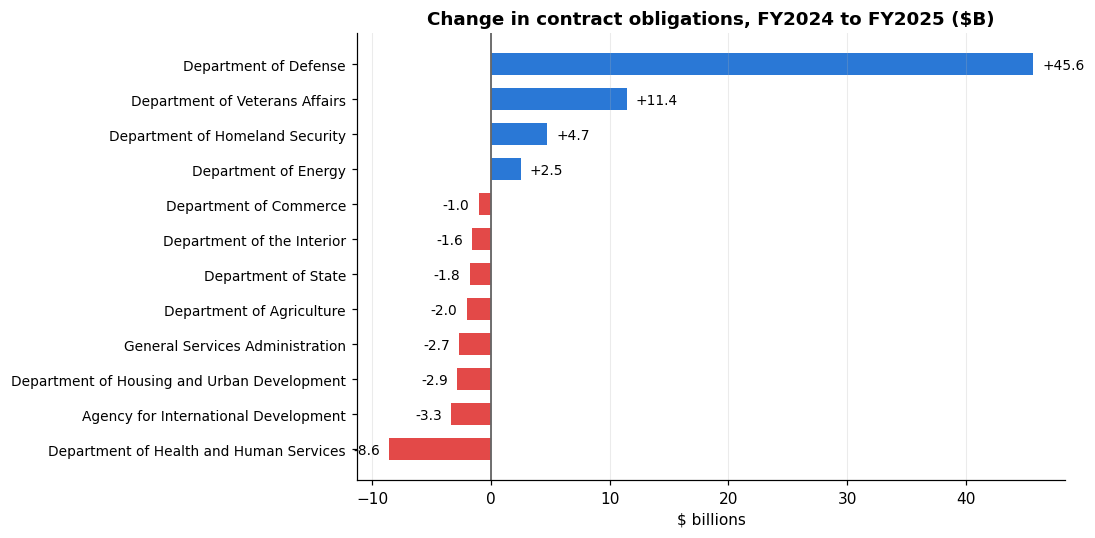

In [11]:
m = fact[fact.fiscal_year == LATEST].copy()
m = m[m.prior_year.notna() & (m.prior_year.abs() > 1e9)]
m['change_bn'] = m.change_abs / 1e9
m = m.reindex(m.change_bn.abs().sort_values(ascending=False).index).head(12).sort_values('change_bn')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(m)), m.change_bn, color=[BLUE if v >= 0 else RED for v in m.change_bn], height=.62)
ax.set_yticks(range(len(m))); ax.set_yticklabels(m.agency_name, fontsize=9)
ax.axvline(0, color='#666', lw=1.2)
for i, v in enumerate(m.change_bn):
    ax.annotate(f'{v:+,.1f}', (v, i), textcoords='offset points',
                xytext=(6 if v >= 0 else -6, -3), ha='left' if v >= 0 else 'right', fontsize=9)
ax.set(title=f'Change in contract obligations, FY{LATEST-1} to FY{LATEST} ($B)', xlabel='$ billions')
ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

In [12]:
cols = {'agency_name':'agency','prior_year':f'FY{LATEST-1} $B','obligations':f'FY{LATEST} $B',
        'change_abs':'change $B','change_pct':'nominal %','change_pct_real':'real %'}
t = m.sort_values('change_bn')[list(cols)].rename(columns=cols)
for c in [f'FY{LATEST-1} $B', f'FY{LATEST} $B', 'change $B']:
    t[c] = (t[c]/1e9).round(2)
t.round(2).reset_index(drop=True)

,agency,FY2024 $B,FY2025 $B,change $B,nominal %,real %
0,Department of Health and Human Services,29.870,21.290,-8.580,-28.720,-30.540
1,Agency for International Development,7.440,4.100,-3.350,-44.940,-46.350
2,Department of Housing and Urban Development,1.530,-1.330,-2.860,-187.310,-185.090
3,General Services Administration,26.500,23.810,-2.690,-10.160,-12.450
4,Department of Agriculture,11.600,9.570,-2.030,-17.490,-19.590
5,Department of State,11.660,9.870,-1.790,-15.360,-17.520
6,Department of the Interior,8.120,6.550,-1.570,-19.290,-21.350
7,Department of Commerce,5.190,4.160,-1.030,-19.790,-21.840
8,Department of Energy,46.040,48.550,2.510,5.440,2.750
9,Department of Homeland Security,23.610,28.340,4.730,20.030,16.970


Concentration moved with it — the market got less distributed, not more:

In [13]:
c = gov[['fiscal_year','agency_hhi','agency_cr4','agency_cr10']].copy()
c['agency HHI'] = c.agency_hhi.round(0)
c['top 4 share %'] = (c.agency_cr4*100).round(1)
c['top 10 share %'] = (c.agency_cr10*100).round(1)
c[['fiscal_year','agency HHI','top 4 share %','top 10 share %']].astype({'fiscal_year':int})

,fiscal_year,agency HHI,top 4 share %,top 10 share %
0,2021,"3,892.000",80.000,92.800
1,2022,"3,872.000",80.100,93.000
2,2023,"3,909.000",79.900,93.000
3,2024,"3,800.000",79.500,92.700
4,2025,"4,158.000",83.000,94.400
